# Task 1 & 2: Add metrics function and Ridge regularization to the LogisticRegression class

In [49]:
import itertools
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from mlflow import MlflowClient
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler


In [ ]:
# from mlflow import tracking

# client = tracking.MlflowClient()

# for exp in client.search_experiments(view_type="ALL"):
#     print(exp.experiment_id, exp.name, exp.lifecycle_stage)

In [ ]:
# client = MlflowClient()

# client.restore_experiment("655500363000293231")

In [50]:
load_dotenv()

mlflow.set_tracking_uri("https://mlflow.ml.brain.cs.ait.ac.th")

In [51]:
def data_cleaning(input_df: pd.DataFrame) -> pd.DataFrame:
    df = input_df.copy()

    # Drop unused columns first to reduce size
    df = df.drop(columns=["torque"])

    # Drop rows that will definitely not be used
    df = df[~df["fuel"].isin(["CNG", "LPG"])]
    df = df[df["owner"] != "Test Drive Car"]

    # Remove Units
    df["mileage"] = df["mileage"].str.split(" ").str[0]
    df["engine"] = df["engine"].str.split(" ").str[0]
    df["max_power"] = df["max_power"].str.split(" ").str[0]

    # Numeric Type conversion
    df["mileage"] = df["mileage"].astype(float)
    df["engine"] = df["engine"].astype(float)
    df["max_power"] = df["max_power"].astype(float)

    # Fix Brand column
    df = df.rename(columns={"name": "brand"})
    df["brand"] = df["brand"].str.split(" ").str[0]

    return df


In [52]:
# This function was added to utils folder for easy workflow during the assignment period
# But I paste it here so that it shows up in the file for submission


def get_preprocessor() -> ColumnTransformer:
    # Define transformers for each feature group
    brand_le = (
        "brand_le",
        Pipeline(
            [
                # Pre-imputer for handling missing values before encoding
                ("pre_imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan)),
                ("post_imputer", SimpleImputer(strategy="most_frequent")),
                # Post-imputer for handling any NaN introduced by unknown categories during encoding
                # So the pipeline is robust to unseen categories in production data
                # This won't happen if frontend limits the choices to existing categories only
                # But it's better to be safe than sorry
            ],
        ),
        ["brand"],
    )

    fuel_le = (
        "fuel_le",
        Pipeline(
            [
                ("pre_imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan)),
                ("post_imputer", SimpleImputer(strategy="most_frequent")),
            ],
        ),
        ["fuel"],
    )

    transmission_le = (
        "transmission_le",
        Pipeline(
            [
                ("pre_imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan)),
                ("post_imputer", SimpleImputer(strategy="most_frequent")),
            ],
        ),
        ["transmission"],
    )

    owner_le = (
        "owner_le",
        Pipeline(
            [
                ("pre_imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OrdinalEncoder(
                        categories=[
                            [
                                "First Owner",
                                "Second Owner",
                                "Third Owner",
                                "Fourth & Above Owner",
                            ],
                        ],
                        handle_unknown="use_encoded_value",
                        unknown_value=np.nan,
                    ),
                ),
                ("post_imputer", SimpleImputer(strategy="most_frequent")),
            ],
        ),
        ["owner"],
    )

    seller_type_ohe = (
        "seller_type_ohe",
        Pipeline(
            [
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")),
            ],
        ),
        ["seller_type"],
    )

    pipeline_steps = [
        (
            "imputer",
            ColumnTransformer(
                transformers=[
                    ("year_imputer", SimpleImputer(strategy="median"), ["year"]),
                    ("km_imputer", SimpleImputer(strategy="median"), ["km_driven"]),
                    ("mileage_imputer", SimpleImputer(strategy="mean"), ["mileage"]),
                    ("engine_imputer", SimpleImputer(strategy="median"), ["engine"]),
                    ("max_power_imputer", SimpleImputer(strategy="median"), ["max_power"]),
                    ("seats_imputer", SimpleImputer(strategy="most_frequent"), ["seats"]),
                ],
                remainder="passthrough",
            ),
        ),
        ("scaler", StandardScaler()),
    ]

    num_scaler = (
        "num_scaler",
        Pipeline(pipeline_steps),
        ["year", "km_driven", "mileage", "engine", "max_power", "seats"],
    )

    # Combine all transformers into the ColumnTransformer
    return ColumnTransformer(
        transformers=[
            brand_le,
            fuel_le,
            transmission_le,
            owner_le,
            seller_type_ohe,
            num_scaler,
        ],
        remainder="passthrough",
        verbose_feature_names_out=True,
    )


In [53]:
# Load, Clean, Split, Preprocess Data
df = pd.read_csv("Cars.csv")
df_train, df_test = train_test_split(df, random_state=42, test_size=0.2)
df_train = data_cleaning(df_train)
df_test = data_cleaning(df_test)
X_train = df_train.drop(columns=["selling_price"])
X_test = df_test.drop(columns=["selling_price"])
y_train = df_train["selling_price"]
y_test = df_test["selling_price"]
preprocessor = get_preprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

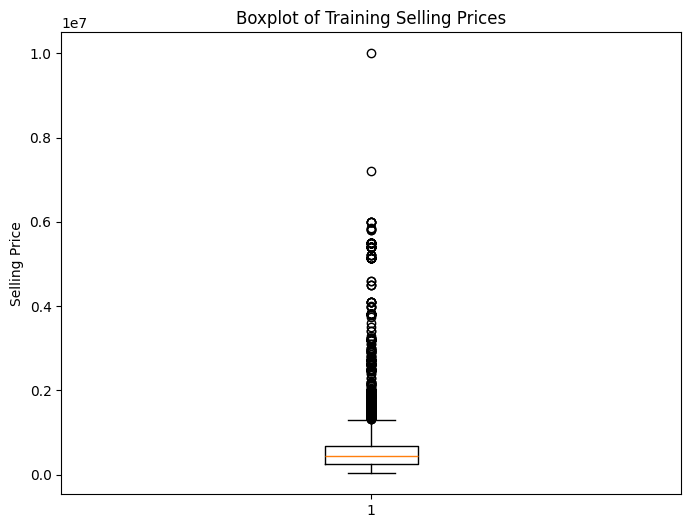

In [54]:
plt.figure(figsize=(8, 6))
plt.boxplot(y_train)
plt.title("Boxplot of Training Selling Prices")
plt.ylabel("Selling Price")
plt.show()

In [55]:
q1 = y_train.quantile(0.25)
q2 = y_train.quantile(0.5)
q3 = y_train.quantile(0.75)
print(f"Q1: {q1}, Q2: {q2}, Q3: {q3}")

Q1: 260000.0, Q2: 450000.0, Q3: 685000.0


In [56]:
y_train_class = pd.cut(
    y_train,
    bins=[-1, q1, q2, q3, np.inf],
    labels=[0, 1, 2, 3],
)
y_test_class = pd.cut(
    y_test,
    bins=[-1, q1, q2, q3, np.inf],
    labels=[0, 1, 2, 3],
)

In [57]:
y_train_class.value_counts()

selling_price
0    1638
1    1616
3    1603
2    1564
Name: count, dtype: int64

In [58]:
# check if the class bin is correct
y_train_class.value_counts()

selling_price
0    1638
1    1616
3    1603
2    1564
Name: count, dtype: int64

In [59]:
y_train_class

6518    2
6144    1
6381    1
438     2
5939    1
       ..
5226    2
5390    2
860     2
7603    3
7270    0
Name: selling_price, Length: 6421, dtype: category
Categories (4, int64): [0 < 1 < 2 < 3]

In [60]:
class LogisticRegression:
    def __init__(self, train_method, alpha, max_iter):
        self.alpha = alpha
        self.max_iter = max_iter
        self.train_method = train_method

    def fit(self, X, Y):
        # Initialize weights randomly
        X_intercept = self.add_intercept(X)
        Y = self.to_one_hot(Y)
        self.n = X_intercept.shape[1]
        self.k = Y.shape[1]
        self.W = np.random.rand(self.n, self.k)
        self.losses = []

        if self.train_method == "batch":
            self.batch_gradient(X_intercept, Y)
        elif self.train_method == "mini-batch":
            self.minibatch_gradient(X_intercept, Y)
        elif self.train_method == "stochastic":
            self.stochastic_gradient(X_intercept, Y)
        else:
            msg = (
                'Method must be one of the followings: "batch", "mini-batch" or "stochastic". '
                "The provided method was + self.train_method"
            )
            raise ValueError(msg)

    def batch_gradient(self, X, Y):
        start_time = time.time()
        for i in range(self.max_iter):
            loss, grad = self.gradient(X, Y)
            self.losses.append(loss)
            self.W = self.W - self.alpha * grad
            if i % 500 == 0:
                print(f"Loss at iteration {i}", loss)
        print(f"time taken: {time.time() - start_time}")

    def minibatch_gradient(self, X, Y):
        start_time = time.time()
        batch_size = int(0.1 * X.shape[0])
        for i in range(self.max_iter):
            batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=True)
            batch_X = X[batch_indices]
            batch_Y = Y[batch_indices]

            loss, grad = self.gradient(batch_X, batch_Y)
            self.losses.append(loss)
            self.W = self.W - self.alpha * grad
            if i % 500 == 0:
                print(f"Loss at iteration {i}", loss)
        print(f"time taken: {time.time() - start_time}")

    def stochastic_gradient(self, X, Y):
        start_time = time.time()
        for i in range(self.max_iter):
            idx = np.random.randint(X.shape[0])
            X_train = X[idx, :].reshape(1, -1)
            Y_train = Y[idx]
            loss, grad = self.gradient(X_train, Y_train)
            self.losses.append(loss)
            self.W = self.W - self.alpha * grad
            if i % 500 == 0:
                print(f"Loss at iteration {i}", loss)
        print(f"time taken: {time.time() - start_time}")

    def gradient(self, X, Y):
        Y_hat = self.h_theta(X, self.W)
        loss = self.cross_entropy(Y, Y_hat)
        grad = X.T @ (Y_hat - Y) / Y.shape[0]
        return loss, grad

    def cross_entropy(self, Y, Y_hat):
        m = Y.shape[0]
        return -np.sum(Y * np.log(Y_hat)) / m

    def softmax(self, theta_t_x):
        return np.exp(theta_t_x) / np.sum(np.exp(theta_t_x), axis=1, keepdims=True)

    def add_intercept(self, X):
        intercept = np.ones((X.shape[0], 1))
        return np.hstack((intercept, X))

    def to_one_hot(self, Y):
        oh_mapping = {
            "0": [1, 0, 0, 0],
            "1": [0, 1, 0, 0],
            "2": [0, 0, 1, 0],
            "3": [0, 0, 0, 1],
        }
        return np.array([oh_mapping[str(label)] for label in Y])

    def h_theta(self, X, W):
        """
        Input:
            X shape: (m, n)
            w shape: (n, k)
        Returns:
            yhat shape: (m, k)
        """
        return self.softmax(X @ W)

    def predict(self, X_test):
        X_test_intercept = self.add_intercept(X_test)
        probabilities = self.h_theta(X_test_intercept, self.W)
        return np.argmax(probabilities, axis=1)

    def predict_proba(self, X_test):
        X_test_intercept = self.add_intercept(X_test)
        return self.h_theta(X_test_intercept, self.W)

    def plot(self):
        plt.plot(np.arange(len(self.losses)), self.losses, label="Train Losses")
        plt.title("Losses")
        plt.xlabel("epoch")
        plt.ylabel("losses")
        plt.legend()

    def true_positives(self, y_true, y_pred, label):
        return np.sum((y_true == label) & (y_pred == label))

    def true_negatives(self, y_true, y_pred, label):
        return np.sum((y_true != label) & (y_pred != label))

    def false_positives(self, y_true, y_pred, label):
        return np.sum((y_true != label) & (y_pred == label))

    def false_negatives(self, y_true, y_pred, label):
        return np.sum((y_true == label) & (y_pred != label))

    def accuracy(self, y_true, y_pred):
        return np.mean(y_true == y_pred)

    def precision(self, y_true, y_pred, label):
        tp = self.true_positives(y_true, y_pred, label)
        fp = self.false_positives(y_true, y_pred, label)
        if (tp + fp) == 0:
            return 0.0
        return tp / (tp + fp)

    def recall(self, y_true, y_pred, label):
        tp = self.true_positives(y_true, y_pred, label)
        fn = self.false_negatives(y_true, y_pred, label)
        if (tp + fn) == 0:
            return 0.0
        return tp / (tp + fn)

    def f1_score(self, y_true, y_pred, label):
        precision = self.precision(y_true, y_pred, label)
        recall = self.recall(y_true, y_pred, label)
        if (precision + recall) == 0:
            return 0.0
        return 2 * (precision * recall) / (precision + recall)

    def macro_precision(self, y_true, y_pred):
        labels = np.unique(y_true)
        precisions = [self.precision(y_true, y_pred, label) for label in labels]
        return np.mean(precisions)

    def macro_recall(self, y_true, y_pred):
        labels = np.unique(y_true)
        recalls = [self.recall(y_true, y_pred, label) for label in labels]
        return np.mean(recalls)

    def macro_f1_score(self, y_true, y_pred):
        labels = np.unique(y_true)
        f1s = [self.f1_score(y_true, y_pred, label) for label in labels]
        return np.mean(f1s)

    def weighted_precision(self, y_true, y_pred):
        labels, counts = np.unique(y_true, return_counts=True)
        precisions = [self.precision(y_true, y_pred, label) for label in labels]
        weighted_precisions = [p * c for p, c in zip(precisions, counts, strict=False)]
        return np.sum(weighted_precisions) / np.sum(counts)

    def weighted_recall(self, y_true, y_pred):
        labels, counts = np.unique(y_true, return_counts=True)
        recalls = [self.recall(y_true, y_pred, label) for label in labels]
        weighted_recalls = [r * c for r, c in zip(recalls, counts, strict=False)]
        return np.sum(weighted_recalls) / np.sum(counts)

    def weighted_f1_score(self, y_true, y_pred):
        labels, counts = np.unique(y_true, return_counts=True)
        f1s = [self.f1_score(y_true, y_pred, label) for label in labels]
        weighted_f1s = [f1 * c for f1, c in zip(f1s, counts, strict=False)]
        return np.sum(weighted_f1s) / np.sum(counts)

    def classification_report(self, y_true, y_pred):
        labels = np.unique(y_true)
        header = "| Label | Precision | Recall | F1-Score |\n|-------|-----------|--------|----------|"
        print(header)
        for label in labels:
            precision = self.precision(y_true, y_pred, label)
            recall = self.recall(y_true, y_pred, label)
            f1 = self.f1_score(y_true, y_pred, label)
            print(f"| {label} | {precision:.4f} | {recall:.4f} | {f1:.4f} |")
        print(
            f"| Macro Avg | {self.macro_precision(y_true, y_pred):.4f} | "
            f"{self.macro_recall(y_true, y_pred):.4f} | "
            f"{self.macro_f1_score(y_true, y_pred):.4f} |",
        )
        print(
            f"| Weighted Avg | {self.weighted_precision(y_true, y_pred):.4f} | "
            f"{self.weighted_recall(y_true, y_pred):.4f} | "
            f"{self.weighted_f1_score(y_true, y_pred):.4f} |",
        )
        print(f"\n**Overall Accuracy:** {self.accuracy(y_true, y_pred):.4f}")


class RidgePenalty:
    def __init__(self, l):
        self.l = l

    def __call__(self, theta):
        return self.l * np.sum(np.square(theta[1:]))

    def derivation(self, theta):
        g = np.zeros_like(theta)
        g[1:] = self.l * 2 * (theta[1:])
        return g


class RidgeLogisticRegression(LogisticRegression):
    def __init__(self, train_method, alpha, max_iter, l=0.1):
        super().__init__(train_method, alpha, max_iter)
        self.penalty = RidgePenalty(l)

    def gradient(self, X, Y):
        m = X.shape[0]
        Y_hat = self.h_theta(X, self.W)
        loss = -np.sum(Y * np.log(Y_hat)) / m + self.penalty(self.W) / m
        grad = X.T @ (Y_hat - Y) + self.penalty.derivation(self.W) / m
        return loss, grad


In [61]:
k = len(y_train_class.unique())
m = X_train_processed.shape[1]
model = LogisticRegression("batch", 0.001, 5000)


In [62]:
model.fit(X_train_processed, y_train_class)
y_pred = model.predict(X_test_processed)
y_pred

Loss at iteration 0 4.536297068477687
Loss at iteration 500 1.5409429825202146
Loss at iteration 1000 1.3657428717422775
Loss at iteration 1500 1.2511066571578204
Loss at iteration 2000 1.1740176952339256
Loss at iteration 2500 1.1196072063237255
Loss at iteration 3000 1.0792089719510243
Loss at iteration 3500 1.0478301390435032
Loss at iteration 4000 1.0225255229656818
Loss at iteration 4500 1.0014938374248081
time taken: 2.254272222518921


array([0, 1, 1, ..., 1, 1, 0], shape=(1607,))

In [63]:
y_pred

array([0, 1, 1, ..., 1, 1, 0], shape=(1607,))

In [64]:
model.classification_report(y_test_class, y_pred)

| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.7127 | 0.8010 | 0.7543 |
| 1 | 0.4720 | 0.4533 | 0.4625 |
| 2 | 0.4052 | 0.3204 | 0.3579 |
| 3 | 0.6066 | 0.6816 | 0.6419 |
| Macro Avg | 0.5491 | 0.5641 | 0.5541 |
| Weighted Avg | 0.5495 | 0.5644 | 0.5545 |

**Overall Accuracy:** 0.5644


=========Classification report=======
              precision    recall  f1-score   support

           0       0.71      0.80      0.75       412
           1       0.47      0.45      0.46       428
           2       0.41      0.32      0.36       387
           3       0.61      0.68      0.64       380

    accuracy                           0.56      1607
   macro avg       0.55      0.56      0.55      1607
weighted avg       0.55      0.56      0.55      1607



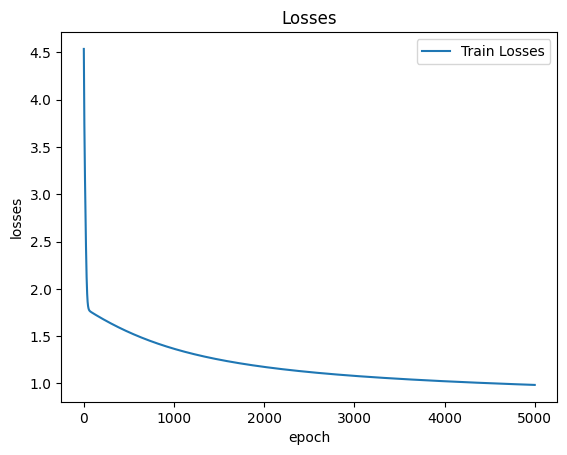

In [65]:
model.plot()
print("=========Classification report=======")
print(classification_report(y_test_class, y_pred))

What does support in the classification report means?
- Support is a number of samples the respective class

# Task 3: Deployment

In [67]:
model_types = ["Normal", "Ridge"]
train_methods = ["batch", "mini-batch", "stochastic"]
learning_rates = [0.01, 0.001]

all_combinations = list(
    itertools.product(
        model_types,
        train_methods,
        learning_rates,
    ),
)
keys = ["model_type", "train_method", "learning_rate"]
params_combinations = [dict(zip(keys, comb, strict=False)) for comb in all_combinations]
len(params_combinations)

12

In [68]:
params_combinations[0]

{'model_type': 'Normal', 'train_method': 'batch', 'learning_rate': 0.01}

In [69]:
def start_experiment(
    X_train_original: pd.DataFrame,
    y_train_original: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    params_combinations: list[dict],
    max_iter: int = 5000,
) -> dict:
    # models = {}
    for i, params in enumerate(params_combinations):
        log_string = f"Reg-{params['model_type']}_TrainMethod-{params['train_method']}_LR-{params['learning_rate']}"
        mlflow.start_run(run_name=log_string)
        mlflow.log_params(params)

        print("=============== Experiment: ", i + 1, " / ", len(params_combinations), "===============")
        print(log_string)

        if params["model_type"] == "Normal":
            model = LogisticRegression(
                train_method=params["train_method"],
                alpha=params["learning_rate"],
                max_iter=max_iter,
            )
        elif params["model_type"] == "Ridge":
            model = RidgeLogisticRegression(
                train_method=params["train_method"],
                alpha=params["learning_rate"],
                max_iter=max_iter,
                l=0.1,
            )
        else:
            print("Error: Please select correct model type.")
            break

        pipeline = Pipeline(
            steps=[
                ("preprocess", get_preprocessor()),
                ("model", model),
            ],
        )

        # After adding all the steps, fit the pipeline
        # The reason to fit the whole pipeline here instead of just the model
        # is to ensure that the shape of X after preprocessing will match the input of model
        # so that during prediction, I can just call pipeline.predict(X) directly
        # using the original X_train without any preprocessing
        # which will be useful during inference in production where input data is raw but human-readable
        pipeline.fit(X_train_original, y_train_original)

        # models[log_string] = pipeline

        y_pred = pipeline.predict(X_test)

        # Get model from pipeline
        # (last step so index = -1)
        # and it's a tuple of (name, model) so get the model with [1]
        fitted_model = pipeline.steps[-1][1]

        pipeline.steps[-1][1].classification_report(y_test, y_pred)

        mlflow.log_metrics(
            metrics={
                "accuracy": fitted_model.accuracy(y_test, y_pred),
                "class_0_precision": fitted_model.precision(y_test, y_pred, 0),
                "class_0_recall": fitted_model.recall(y_test, y_pred, 0),
                "class_0_f1": fitted_model.f1_score(y_test, y_pred, 0),
                "class_1_precision": fitted_model.precision(y_test, y_pred, 1),
                "class_1_recall": fitted_model.recall(y_test, y_pred, 1),
                "class_1_f1": fitted_model.f1_score(y_test, y_pred, 1),
                "class_2_precision": fitted_model.precision(y_test, y_pred, 2),
                "class_2_recall": fitted_model.recall(y_test, y_pred, 2),
                "class_2_f1": fitted_model.f1_score(y_test, y_pred, 2),
                "class_3_precision": fitted_model.precision(y_test, y_pred, 3),
                "class_3_recall": fitted_model.recall(y_test, y_pred, 3),
                "class_3_f1": fitted_model.f1_score(y_test, y_pred, 3),
                "macro_precision": fitted_model.macro_precision(y_test, y_pred),
                "macro_recall": fitted_model.macro_recall(y_test, y_pred),
                "macro_f1": fitted_model.macro_f1_score(y_test, y_pred),
                "weighted_precision": fitted_model.weighted_precision(y_test, y_pred),
                "weighted_recall": fitted_model.weighted_recall(y_test, y_pred),
                "weighted_f1": fitted_model.weighted_f1_score(y_test, y_pred),
            },
        )

        # Below this is the old code provided in Regularization.ipynb
        # which saves only the last fold model which is not correct
        # I will refit the model with the best params and save the model later
        signature = mlflow.models.infer_signature(X_train_original, pipeline.predict(X_train_original))
        mlflow.sklearn.log_model(pipeline, name="model", signature=signature)
        mlflow.end_run()
    # return models

In [70]:
# suppress overflow warnings for log
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    start_experiment(
        X_train,
        y_train_class,
        X_test,
        y_test_class,
        params_combinations=params_combinations,
        max_iter=5000,
    )

=============== Experiment:  1  /  12 ===============
Reg-Normal_TrainMethod-batch_LR-0.01
Loss at iteration 0 7.274561687315457
Loss at iteration 500 0.9725631997038706
Loss at iteration 1000 0.869082460435639
Loss at iteration 1500 0.8207499429042737
Loss at iteration 2000 0.7911486882121362
Loss at iteration 2500 0.7707920061958217
Loss at iteration 3000 0.7558022989507028
Loss at iteration 3500 0.7442427480914774
Loss at iteration 4000 0.7350268191120306
Loss at iteration 4500 0.7274933898843265
time taken: 2.2720985412597656
| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.8153 | 0.8252 | 0.8203 |
| 1 | 0.5674 | 0.5607 | 0.5640 |
| 2 | 0.5304 | 0.5633 | 0.5464 |
| 3 | 0.8034 | 0.7526 | 0.7772 |
| Macro Avg | 0.6791 | 0.6755 | 0.6770 |
| Weighted Avg | 0.6779 | 0.6745 | 0.6759 |

**Overall Accuracy:** 0.6745


d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoi

🏃 View run Reg-Normal_TrainMethod-batch_LR-0.01 at: https://mlflow.ml.brain.cs.ait.ac.th/#/experiments/655500363000293231/runs/e244499ea8b34307ba1b7d086b2abbaf
🧪 View experiment at: https://mlflow.ml.brain.cs.ait.ac.th/#/experiments/655500363000293231
=============== Experiment:  2  /  12 ===============
Reg-Normal_TrainMethod-batch_LR-0.001
Loss at iteration 0 5.183729645861908
Loss at iteration 500 1.5720900448696151
Loss at iteration 1000 1.3881123454277533
Loss at iteration 1500 1.2674127436914282
Loss at iteration 2000 1.1855719131892937
Loss at iteration 2500 1.1270535064301337
Loss at iteration 3000 1.083335583454253
Loss at iteration 3500 1.0495552158884878
Loss at iteration 4000 1.0224214897600636
Loss at iteration 4500 0.9999714450087692
time taken: 2.2775509357452393
| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.6989 | 0.7888 | 0.7412 |
| 1 | 0.3714 | 0.3341 | 0.3518 |
| 2 | 0.4458 | 0.4574 | 0.4515 |
| 3 | 0.6611 | 0.6263 | 0.64

d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoi

🏃 View run Reg-Normal_TrainMethod-batch_LR-0.001 at: https://mlflow.ml.brain.cs.ait.ac.th/#/experiments/655500363000293231/runs/c24994334ca445bc8d0ae7b24e537bb8
🧪 View experiment at: https://mlflow.ml.brain.cs.ait.ac.th/#/experiments/655500363000293231
=============== Experiment:  3  /  12 ===============
Reg-Normal_TrainMethod-mini-batch_LR-0.01
Loss at iteration 0 7.118725228103791
Loss at iteration 500 0.9594986213682566
Loss at iteration 1000 0.869120439534371
Loss at iteration 1500 0.830124012180488
Loss at iteration 2000 0.7847347468530538
Loss at iteration 2500 0.7284817803637412
Loss at iteration 3000 0.7649257299134246
Loss at iteration 3500 0.759609523228107
Loss at iteration 4000 0.7331933374251739
Loss at iteration 4500 0.7215822390483262
time taken: 0.4195241928100586
| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.7963 | 0.8350 | 0.8152 |
| 1 | 0.5753 | 0.5444 | 0.5594 |
| 2 | 0.5293 | 0.6072 | 0.5656 |
| 3 | 0.8313 | 0.7132 | 0

...

🏃 View run Reg-Ridge_TrainMethod-mini-batch_LR-0.001 at: https://mlflow.ml.brain.cs.ait.ac.th/#/experiments/655500363000293231/runs/6c4aa581766b40b3bc43727919e6a2d4
🧪 View experiment at: https://mlflow.ml.brain.cs.ait.ac.th/#/experiments/655500363000293231
=============== Experiment:  11  /  12 ===============
Reg-Ridge_TrainMethod-stochastic_LR-0.01
Loss at iteration 0 2.4216931036501195
Loss at iteration 500 0.6114278897586755
Loss at iteration 1000 0.8854149792887754
Loss at iteration 1500 2.097432451429847
Loss at iteration 2000 4.5151160515511215
Loss at iteration 2500 2.122624704527534
Loss at iteration 3000 1.1731055433033575
Loss at iteration 3500 2.499667909281991
Loss at iteration 4000 3.9046917225113913
Loss at iteration 4500 2.1020780472203895
time taken: 0.09350252151489258
| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.8076 | 0.5704 | 0.6686 |
| 1 | 0.4486 | 0.7757 | 0.5685 |
| 2 | 0.0000 | 0.0000 | 0.0000 |
| 3 | 0.5694 | 0.86

d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoi

🏃 View run Reg-Ridge_TrainMethod-stochastic_LR-0.01 at: https://mlflow.ml.brain.cs.ait.ac.th/#/experiments/655500363000293231/runs/993c25ed1bba47758b3f1ec94a381aa4
🧪 View experiment at: https://mlflow.ml.brain.cs.ait.ac.th/#/experiments/655500363000293231
=============== Experiment:  12  /  12 ===============
Reg-Ridge_TrainMethod-stochastic_LR-0.001
Loss at iteration 0 5.31915522403085
Loss at iteration 500 4.876967835595418
Loss at iteration 1000 2.0292809729025594
Loss at iteration 1500 2.835883773427633
Loss at iteration 2000 1.65925666501297
Loss at iteration 2500 1.7550477073267188
Loss at iteration 3000 1.88040993328811
Loss at iteration 3500 2.215072184355758
Loss at iteration 4000 1.8261149711093494
Loss at iteration 4500 1.6861428444648399
time taken: 0.0899662971496582
| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.7864 | 0.6165 | 0.6912 |
| 1 | 0.3525 | 0.8037 | 0.4900 |
| 2 | 0.4000 | 0.0052 | 0.0102 |
| 3 | 0.7756 | 0.6184 | 0.

d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoi

🏃 View run Reg-Ridge_TrainMethod-stochastic_LR-0.001 at: https://mlflow.ml.brain.cs.ait.ac.th/#/experiments/655500363000293231/runs/17b5fe8a625e4b2bb300d2995d48d056
🧪 View experiment at: https://mlflow.ml.brain.cs.ait.ac.th/#/experiments/655500363000293231


In [ ]:
mlflow.end_run()  # just in case there is some run stuck

In [71]:
runs = mlflow.search_runs(experiment_names=["st125923-a3"], search_all_experiments=False, output_format="pandas")

In [72]:
runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.class_1_f1,metrics.macro_f1,metrics.class_3_recall,metrics.class_1_precision,...,metrics.class_0_f1,metrics.class_2_recall,metrics.class_0_precision,params.learning_rate,params.model_type,params.train_method,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.type
0,17b5fe8a625e4b2bb300d2995d48d056,655500363000293231,FINISHED,mlflow-artifacts:/655500363000293231/17b5fe8a6...,2025-10-05 04:10:10.406000+00:00,2025-10-05 04:10:23.467000+00:00,0.490028,0.469882,0.618421,0.352459,...,0.691156,0.005168,0.786378,0.001,Ridge,stochastic,admin,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...,Reg-Ridge_TrainMethod-stochastic_LR-0.001,LOCAL
1,993c25ed1bba47758b3f1ec94a381aa4,655500363000293231,FINISHED,mlflow-artifacts:/655500363000293231/993c25ed1...,2025-10-05 04:09:56.848000+00:00,2025-10-05 04:10:10.019000+00:00,0.568493,0.480812,0.863158,0.448649,...,0.668563,0.000000,0.807560,0.01,Ridge,stochastic,admin,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...,Reg-Ridge_TrainMethod-stochastic_LR-0.01,LOCAL
2,6c4aa581766b40b3bc43727919e6a2d4,655500363000293231,FINISHED,mlflow-artifacts:/655500363000293231/6c4aa5817...,2025-10-05 04:09:42.929000+00:00,2025-10-05 04:09:56.452000+00:00,0.004630,0.511055,0.597368,0.250000,...,0.739172,0.839793,0.612440,0.001,Ridge,mini-batch,admin,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...,Reg-Ridge_TrainMethod-mini-batch_LR-0.001,LOCAL
3,e3f29c05e01040af89163883ff3487b2,655500363000293231,FINISHED,mlflow-artifacts:/655500363000293231/e3f29c05e...,2025-10-05 04:09:29.397000+00:00,2025-10-05 04:09:42.547000+00:00,0.000000,0.102031,0.000000,0.000000,...,0.408123,0.000000,0.256378,0.01,Ridge,mini-batch,admin,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...,Reg-Ridge_TrainMethod-mini-batch_LR-0.01,LOCAL
4,6c52ec9c6977461fa2b8f976c797dd6a,655500363000293231,FINISHED,mlflow-artifacts:/655500363000293231/6c52ec9c6...,2025-10-05 04:09:14.481000+00:00,2025-10-05 04:09:29.014000+00:00,0.000000,0.102031,0.000000,0.000000,...,0.408123,0.000000,0.256378,0.001,Ridge,batch,admin,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...,Reg-Ridge_TrainMethod-batch_LR-0.001,LOCAL
5,e93568fb59c140ea98f4b0b21121db41,655500363000293231,FINISHED,mlflow-artifacts:/655500363000293231/e93568fb5...,2025-10-05 04:08:59.606000+00:00,2025-10-05 04:09:14.103000+00:00,0.000000,0.102031,0.000000,0.000000,...,0.408123,0.000000,0.256378,0.01,Ridge,batch,admin,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...,Reg-Ridge_TrainMethod-batch_LR-0.01,LOCAL
6,af0a4f9cc1d04b10a58d3d05abd9a9f1,655500363000293231,FINISHED,mlflow-artifacts:/655500363000293231/af0a4f9cc...,2025-10-05 04:08:46.418000+00:00,2025-10-05 04:08:59.226000+00:00,0.157303,0.308983,0.626316,0.251282,...,0.358524,0.134367,0.280992,0.001,Normal,stochastic,admin,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...,Reg-Normal_TrainMethod-stochastic_LR-0.001,LOCAL
7,867555e8947b4098ae352fc04cafc4a4,655500363000293231,FINISHED,mlflow-artifacts:/655500363000293231/867555e89...,2025-10-05 04:08:31.727000+00:00,2025-10-05 04:08:46.040000+00:00,0.503488,0.445219,0.571053,0.345518,...,0.544538,0.028424,0.885246,0.01,Normal,stochastic,admin,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...,Reg-Normal_TrainMethod-stochastic_LR-0.01,LOCAL
8,64283aa17e6948169d97a7b3a5094fca,655500363000293231,FINISHED,mlflow-artifacts:/655500363000293231/64283aa17...,2025-10-05 04:08:18.028000+00:00,2025-10-05 04:08:31.350000+00:00,0.450331,0.565125,0.681579,0.426778,...,0.767468,0.310078,0.726681,0.001,Normal,mini-batch,admin,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...,Reg-Normal_TrainMethod-mini-batch_LR-0.001,LOCAL
9,59c6d8712e95455f85b814e7381d170a,655500363000293231,FINISHED,mlflow-artifacts:/655500363000293231/59c6d8712...,2025-10-05 04:08:04.194000+00:00,2025-10-05 04:08:17.634000+00:00,0.559424,0.676970,0.713158,0.575309,...,0.815166,0.607235,0.796296,0.01,Normal,mini-batch,admin,d:\AT82.03-ML-Car-Price-Pre

In [73]:
runs[["tags.mlflow.runName", "metrics.macro_f1", "metrics.weighted_f1", "metrics.accuracy"]].sort_values(
    by="metrics.macro_f1",
    ascending=False,
)

,tags.mlflow.runName,metrics.macro_f1,metrics.weighted_f1,metrics.accuracy
9,Reg-Normal_TrainMethod-mini-batch_LR-0.01,0.676970,0.675725,0.673927
11,Reg-Normal_TrainMethod-batch_LR-0.01,0.676962,0.675874,0.674549
8,Reg-Normal_TrainMethod-mini-batch_LR-0.001,0.565125,0.564781,0.571251
10,Reg-Normal_TrainMethod-batch_LR-0.001,0.546930,0.544553,0.549471
2,Reg-Ridge_TrainMethod-mini-batch_LR-0.001,0.511055,0.500805,0.583074
1,Reg-Ridge_TrainMethod-stochastic_LR-0.01,0.480812,0.485075,0.556938
0,Reg-Ridge_TrainMethod-stochastic_LR-0.001,0.469882,0.472888,0.519602
7,Reg-Normal_TrainMethod-stochastic_LR-0.01,0.445219,0.447236,0.489732
6,Reg-Normal_TrainMethod-stochastic_LR-0.001,0.308983,0.304895,0.337897
3,Reg-Ridge_TrainMethod-mini-batch_LR-0.01,0.102031,0.104634,0.256378


In [74]:
best_run_id = runs.sort_values("metrics.macro_f1", ascending=False).iloc[0]["run_id"]
best_run_name = runs.sort_values("metrics.macro_f1", ascending=False).iloc[0]["tags.mlflow.runName"]

In [75]:
print(best_run_id)
print(best_run_name)

59c6d8712e95455f85b814e7381d170a
Reg-Normal_TrainMethod-mini-batch_LR-0.01


### After Registering the model in MLflow UI

In [77]:
client = MlflowClient()

In [78]:
client.set_registered_model_alias("st125923-a3-model", "staging", 1)

In [79]:
loaded_model = mlflow.sklearn.load_model("models:/st125923-a3-model@staging")

In [80]:
loaded_model

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('brand_le', ...), ('fuel_le', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
# Recheck if the loaded model works correctly
print(classification_report(y_test_class, loaded_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.83      0.82       412
           1       0.58      0.54      0.56       428
           2       0.53      0.61      0.57       387
           3       0.83      0.71      0.77       380

    accuracy                           0.67      1607
   macro avg       0.68      0.67      0.68      1607
weighted avg       0.68      0.67      0.68      1607



d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
